# Linear Regression Model

Existing studies on waste bin fill-level prediction commonly adopt linear or regression-based approaches as an initial benchmark to estimate short-term fill behaviour and support collection planning. These studies subsequently apply more advanced models, such as Gaussian Process Regression, which have been shown to achieve better predictive performance (Brouwer et al., 2023; Ferrer & Alba, 2019; Krishna et al., 2025).

In line with these studies, Linear Regression is applied in this project to predict short-term bin fill levels using features derived from the sensor dataset, such as the current fill percentage and time since the last collection. As the ultrasonic sensor readings are recorded at irregular time intervals rather than fixed daily intervals, the next observed fill level is treated as a next-day fill estimate for collection planning purposes.



‌



In [88]:
from datasets import load_dataset
import pandas as pd

dataset = load_dataset("SA61team5/AD-tableA")

df = pd.DataFrame(dataset["train"])

print(df.shape)


(45805, 9)


In [89]:
df.head(10)

,ContainerID,timestamp,fill_percentage,Cidx,Rec,month,is_weekend,days_since_last_REC,next_observation_fill_percentage
0,1000,2021-01-16 11:30:00,52.5,0.0,1,1,1,0.000000,52.5
1,1000,2021-01-16 12:28:00,52.5,0.0,0,1,1,0.040278,52.5
2,1000,2021-01-16 13:28:00,52.5,0.0,0,1,1,0.081944,52.5
3,1000,2021-01-17 12:34:00,52.5,0.0,0,1,1,1.044444,52.5
4,1000,2021-01-18 12:41:00,52.5,0.0,0,1,0,2.049306,52.5
5,1000,2021-01-19 12:48:00,52.5,0.0,0,1,0,3.054167,52.5
6,1000,2021-01-20 12:55:00,52.5,0.0,0,1,0,4.059028,52.5
7,1000,2021-01-20 18:27:00,52.5,0.0,0,1,0,4.289583,52.5
8,1000,2021-01-21 13:02:00,52.5,0.0,0,1,0,5.063889,52.5
9,1000,2021-01-22 13:07:00,52.5,0.0,0,1,0,6.067361,52.5


## Time-based train-test split

Instead of randomly splitting the data, earlier records will be used for training while later records are reserved for testing.

In [90]:
df["timestamp"] = pd.to_datetime(df["timestamp"])
split_date = df["timestamp"].quantile(0.8)

train_df = df[df["timestamp"] <= split_date]
test_df  = df[df["timestamp"] > split_date]

features = ["fill_percentage","month", "is_weekend", "days_since_last_REC"]

X_train = train_df[features]
y_train = train_df["next_observation_fill_percentage"]

X_test  = test_df[features]
y_test  = test_df["next_observation_fill_percentage"]

## Model Training

In [91]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

## Model Prediction

In [92]:
y_pred = model.predict(X_test)

## Model Evaluation
Mean Absolute Error (MAE) is used to measure the average absolute difference between the predicted and actual bin fill levels, indicating how far predictions typically deviate from actual fill levels. (Ferrer & Alba, 2019; Krishna et al., 2025).

Root Mean Squared Error (RMSE) is used to assess the impact of large errors on planning decisions (Krishna et al., 2025).

MAE at high fill levels (≥80%) is used to evaluate model performance when bins are close to being full. This is important because prediction accuracy near collection thresholds has a greater impact on operational decision-making than average fill behaviour.

In [93]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")

high_fill_mask = y_test >= 70

mae_high = mean_absolute_error(
    y_test[high_fill_mask],
    y_pred[high_fill_mask]
)

print(f"MAE @ High Fill (≥70%) : {mae_high:.2f}")

MAE  : 9.52
RMSE : 16.89
MAE @ High Fill (≥70%) : 18.17


## Intepreting Evaluation Results
1) MAE = 9.52

    On average, the model’s predicted bin fill level differs from the actual fill level by about 9.5 percentage points.

2) RMSE = 16.89

    RMSE indicates that while most predictions deviate from the actual fill level by about 9.5 percentage points, there are cases where larger errors occur, with deviations of up to around 16.9 percentage points. These larger errors may occur during irregular fill behaviour, such as sudden increases in usage or or variations related to collection schedules.

3) R2 = 0.576

    An R² value of 0.576 indicates that approximately 57.6% of the variance in next-day bin fill levels is explained by the model. 

3) MAE @ High Fill (≥80%) = 19.26

    When bins are close to being full, the average prediction error increases to about 19 percentage points. This suggests that the Linear Regression model struggles more in high-risk situations near collection thresholds, where fill behaviour may become less linear or more variable. This limitation highlights why Linear Regression is suitable as a baseline model but may not be sufficient on its own for accurate overflow risk prediction.

## Partial Dependence Plot 
Partial Dependence Plots were used to analyse how each feature influences the predicted next fill level while holding other features constant. 

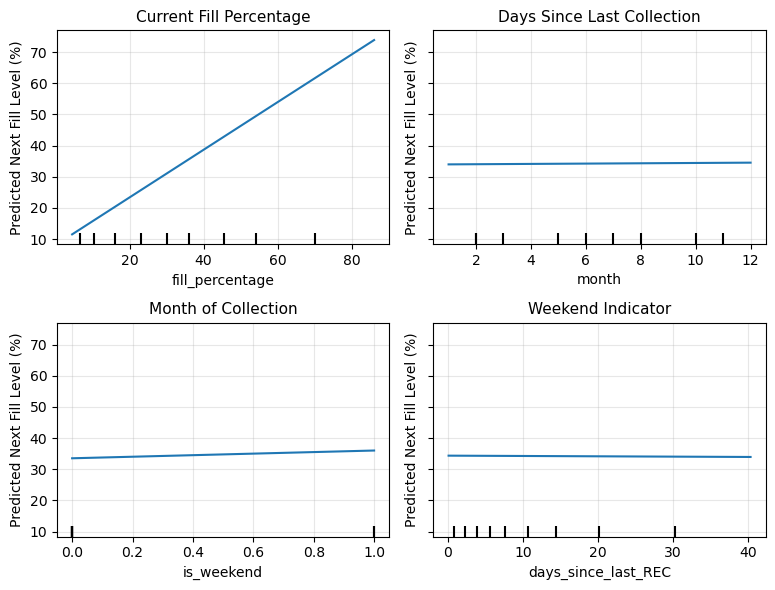

In [94]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(8, 6)
)

disp = PartialDependenceDisplay.from_estimator(
    model,
    X_train,
    features=features,
    ax=ax,
    grid_resolution=60
)

titles = ["Current Fill Percentage", "Days Since Last Collection", "Month of Collection", "Weekend Indicator"]

for i, axi in enumerate(ax.flat):
    axi.set_title(titles[i], fontsize=11)
    axi.set_xlabel(features[i], fontsize=10)
    axi.set_ylabel("Predicted Next Fill Level (%)", fontsize=10)
    axi.grid(alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 1])
plt.show()

From the partial dependence plots, it can be seen that the current fill percentage is the main factor influencing the next predicted fill level. Other temporal features, such as days since last collection, month, and weekend indicator, have a much smaller effect on the model’s predictions when considered on their own.

## References

Brouwer, Y., Ana Paula Barbosa-Póvoa, António Pais Antunes, & Rodrigues, T. (2023). Comparison of different waste bin monitoring approaches: An exploratory study. Waste Management & Research (Online), 41(10), 1570–1583. https://doi.org/10.1177/0734242x231160691
‌

Ferrer, J., & Alba, E. (2019). BIN-CT: Urban waste collection based on predicting the container fill level. Biosystems, 186, 103962. https://doi.org/10.1016/j.biosystems.2019.04.006

Krishna, S. R., Bhukya Kranthikumar, Swathy Vodithala, Waseem, Md. Sharfuddin., & Kireet Muppavaram. (2025). A Machine Learning Framework For Predictive Waste Management Optimization In Smart Cities. International Journal of Environmental Sciences, 11(12s), 328–334. https://doi.org/10.64252/zp92vp11

In [103]:
# Deploy model

import joblib
import os

joblib.dump(model, "../model.pkl")

['../model.pkl']

In [96]:
# Test prediction

import pandas as pd

X_test_manual = pd.DataFrame([{
    "fill_percentage": 40,
    "month": 1,
    "is_weekend": 0,
    "days_since_last_REC": 1
}])

pred = model.predict(X_test_manual)
print("Raw prediction:", pred)

Raw prediction: [37.81754152]
